In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os

DATA_DIR = "/content/drive/My Drive/AIO_Homework/transformer decoder/data"
SRC_FILE = os.path.join(DATA_DIR,"en_sents")
TGT_FILE = os.path.join(DATA_DIR, 'vi_sents')
# Kiểm tra file tồn tại
print("en_sents:", os.path.exists(SRC_FILE))
print("vi_sents:", os.path.exists(TGT_FILE))

en_sents: True
vi_sents: True


In [13]:
import math, torch, torch.nn as nn, torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from tqdm import tqdm
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

SRC_VOCAB_SIZE  = 8000; TGT_VOCAB_SIZE = 8000
D_MODEL    = 256;  NUM_HEADS = 8;   NUM_LAYERS = 3
D_FF       = 512;  DROPOUT   = 0.1; MAX_LEN    = 64
BATCH_SIZE = 64;   NUM_EPOCHS = 10; LR         = 1e-4
N_SAMPLES  = 50000

Device: cuda


In [4]:
def load_pairs(src_file, tgt_file, n=None):
    with open(src_file, encoding="utf-8") as f:
        src_lines = [l.strip() for l in f if l.strip()]
    with open(tgt_file, encoding="utf-8") as f:
        tgt_lines = [l.strip() for l in f if l.strip()]
    pairs = list(zip(src_lines, tgt_lines))
    if n: pairs = pairs[:n]
    print(f"Loaded {len(pairs):,} pairs"); return pairs

def tokenize(text): return text.lower().split()

def build_vocab(sentences, max_vocab=8000):
    counter = Counter()
    for s in sentences: counter.update(tokenize(s))
    vocab = {"<PAD>": 0, "<UNK>": 1, "<BOS>": 2, "<EOS>": 3}
    for w, _ in counter.most_common(max_vocab - len(vocab)):
        vocab[w] = len(vocab)
    return vocab

def encode(sentence, vocab, max_len=MAX_LEN):
    tokens = tokenize(sentence)[:max_len - 2]
    ids = [vocab["<BOS>"]] + [vocab.get(t, vocab["<UNK>"]) for t in tokens] + [vocab["<EOS>"]]
    ids += [vocab["<PAD>"]] * (max_len - len(ids))
    return ids[:max_len]

class TranslationDataset(Dataset):
    def __init__(self, pairs, src_vocab, tgt_vocab, max_len=MAX_LEN):
        self.src = [torch.tensor(encode(s, src_vocab, max_len), dtype=torch.long) for s,_ in tqdm(pairs)]
        self.tgt = [torch.tensor(encode(t, tgt_vocab, max_len), dtype=torch.long) for _,t in tqdm(pairs)]
    def __len__(self): return len(self.src)
    def __getitem__(self, i): return self.src[i], self.tgt[i]

In [5]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=512, dropout=0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).float().unsqueeze(1)
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0)/d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])

class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, num_heads, dropout=0.1):
        super().__init__()
        assert d_model % num_heads == 0
        self.h = num_heads; self.d_k = d_model // num_heads; self.d = d_model
        self.q = nn.Linear(d_model, d_model); self.k = nn.Linear(d_model, d_model)
        self.v = nn.Linear(d_model, d_model); self.o = nn.Linear(d_model, d_model)
        self.drop = nn.Dropout(dropout)
    def forward(self, q, k, v, mask=None):
        B = q.size(0)
        q = self.q(q).view(B,-1,self.h,self.d_k).transpose(1,2)
        k = self.k(k).view(B,-1,self.h,self.d_k).transpose(1,2)
        v = self.v(v).view(B,-1,self.h,self.d_k).transpose(1,2)
        sc = torch.matmul(q, k.transpose(-2,-1)) / math.sqrt(self.d_k)
        if mask is not None: sc = sc.masked_fill(mask==0, -1e9)
        attn = self.drop(F.softmax(sc, dim=-1))
        out = torch.matmul(attn, v).transpose(1,2).contiguous().view(B,-1,self.d)
        return self.o(out), attn

class FFN(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(d_model,d_ff), nn.ReLU(), nn.Dropout(dropout), nn.Linear(d_ff,d_model))
    def forward(self, x): return self.net(x)

In [6]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        self.attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.ffn  = FFN(d_model, d_ff, dropout)
        self.n1   = nn.LayerNorm(d_model); self.n2 = nn.LayerNorm(d_model)
        self.d1   = nn.Dropout(dropout);   self.d2 = nn.Dropout(dropout)
    def forward(self, x, mask=None):
        a, _ = self.attn(x, x, x, mask=mask)
        x = self.n1(x + self.d1(a))
        x = self.n2(x + self.d2(self.ffn(x)))
        return x

class TransformerEncoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=512, dropout=0.1):
        super().__init__()
        self.emb    = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos    = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([EncoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.norm   = nn.LayerNorm(d_model)
    def forward(self, x, mask=None):
        out = self.pos(self.emb(x))
        for layer in self.layers: out = layer(out, mask)
        return self.norm(out)

In [7]:

class DecoderLayer(nn.Module):
    def __init__(self, d_model, num_heads, d_ff, dropout=0.1):
        super().__init__()
        # Sub-layer 1: Masked Self-Attention (causal)
        self.self_attn  = MultiHeadAttention(d_model, num_heads, dropout)
        self.norm1      = nn.LayerNorm(d_model)
        self.drop1      = nn.Dropout(dropout)
        # Sub-layer 2: Cross-Attention (Q=decoder, K/V=encoder)
        self.cross_attn = MultiHeadAttention(d_model, num_heads, dropout)
        self.norm2      = nn.LayerNorm(d_model)
        self.drop2      = nn.Dropout(dropout)
        # Sub-layer 3: Feed-Forward
        self.ffn        = FFN(d_model, d_ff, dropout)
        self.norm3      = nn.LayerNorm(d_model)
        self.drop3      = nn.Dropout(dropout)

    def forward(self, tgt, enc_out, tgt_mask=None, src_mask=None):
        # 1. Masked Self-Attention
        a1, _ = self.self_attn(tgt, tgt, tgt, mask=tgt_mask)
        tgt   = self.norm1(tgt + self.drop1(a1))
        # 2. Cross-Attention: Q từ decoder, K/V từ encoder
        a2, _ = self.cross_attn(tgt, enc_out, enc_out, mask=src_mask)
        tgt   = self.norm2(tgt + self.drop2(a2))
        # 3. Feed-Forward
        tgt   = self.norm3(tgt + self.drop3(self.ffn(tgt)))
        return tgt

class TransformerDecoder(nn.Module):
    def __init__(self, vocab_size, d_model, num_layers, num_heads, d_ff, max_len=512, dropout=0.1):
        super().__init__()
        self.emb    = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.pos    = PositionalEncoding(d_model, max_len, dropout)
        self.layers = nn.ModuleList([DecoderLayer(d_model, num_heads, d_ff, dropout) for _ in range(num_layers)])
        self.norm   = nn.LayerNorm(d_model)
    def forward(self, tgt, enc_out, tgt_mask=None, src_mask=None):
        out = self.pos(self.emb(tgt))
        for layer in self.layers:
            out = layer(out, enc_out, tgt_mask=tgt_mask, src_mask=src_mask)
        return self.norm(out)

In [8]:
class Seq2SeqTransformer(nn.Module):
    def __init__(self, src_vocab, tgt_vocab, d_model, num_layers, num_heads, d_ff, max_len=512, dropout=0.1):
        super().__init__()
        self.encoder  = TransformerEncoder(src_vocab, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.decoder  = TransformerDecoder(tgt_vocab, d_model, num_layers, num_heads, d_ff, max_len, dropout)
        self.out_proj = nn.Linear(d_model, tgt_vocab)
    def forward(self, src, tgt, src_mask=None, tgt_mask=None):
        enc = self.encoder(src, src_mask)
        dec = self.decoder(tgt, enc, tgt_mask, src_mask)
        return self.out_proj(dec)

def make_src_mask(src, pad=0):
    return (src != pad).unsqueeze(1).unsqueeze(2)          # [B,1,1,S]

def make_tgt_mask(tgt, pad=0):
    T = tgt.size(1)
    causal = torch.tril(torch.ones(T, T, device=tgt.device)).bool().unsqueeze(0).unsqueeze(0)
    pad_mask = (tgt != pad).unsqueeze(1).unsqueeze(2)
    return causal & pad_mask                               # [B,1,T,T]

In [9]:
def train_epoch(model, loader, optimizer, criterion, pad_idx):
    model.train()
    total = 0.0
    for src, tgt in tqdm(loader, desc="Train"):
        src, tgt = src.to(device), tgt.to(device)
        tgt_inp  = tgt[:, :-1]   # bỏ token cuối
        tgt_out  = tgt[:, 1:]    # bỏ <BOS>
        src_mask = make_src_mask(src, pad_idx)
        tgt_mask = make_tgt_mask(tgt_inp, pad_idx)
        optimizer.zero_grad()
        logits = model(src, tgt_inp, src_mask, tgt_mask)
        loss   = criterion(logits.reshape(-1, logits.size(-1)), tgt_out.reshape(-1))
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total += loss.item()
    return total / len(loader)

def eval_epoch(model, loader, criterion, pad_idx):
    model.eval()
    total = 0.0
    with torch.no_grad():
        for src, tgt in loader:
            src, tgt = src.to(device), tgt.to(device)
            tgt_inp  = tgt[:, :-1]
            tgt_out  = tgt[:, 1:]
            logits   = model(src, tgt_inp,
                             make_src_mask(src, pad_idx),
                             make_tgt_mask(tgt_inp, pad_idx))
            total += criterion(logits.reshape(-1, logits.size(-1)),
                               tgt_out.reshape(-1)).item()
    return total / len(loader)


In [10]:
# ── 1. GREEDY SEARCH ─────────────────────────────────────────────────────────
def greedy_decode(sentence, model, src_vocab, tgt_vocab, max_len=MAX_LEN):
    model.eval()
    idx2w = {v: k for k, v in tgt_vocab.items()}
    src   = torch.tensor([encode(sentence, src_vocab, max_len)],
                         dtype=torch.long).to(device)
    smask = make_src_mask(src)
    with torch.no_grad():
        enc     = model.encoder(src, smask)
        tgt_ids = [tgt_vocab["<BOS>"]]
        for _ in range(max_len - 1):
            t     = torch.tensor([tgt_ids], dtype=torch.long).to(device)
            tmask = make_tgt_mask(t)
            dec   = model.decoder(t, enc, tmask, smask)
            nxt   = model.out_proj(dec)[0, -1].argmax(-1).item()
            tgt_ids.append(nxt)
            if nxt == tgt_vocab["<EOS>"]:
                break
    tokens = [idx2w.get(i, "<UNK>") for i in tgt_ids[1:]
              if i not in (tgt_vocab["<PAD>"], tgt_vocab["<EOS>"])]
    return " ".join(tokens)


# ── 2. BEAM SEARCH ───────────────────────────────────────────────────────────
def beam_decode(sentence, model, src_vocab, tgt_vocab,
                max_len=MAX_LEN, beam_size=4):
    model.eval()
    idx2w = {v: k for k, v in tgt_vocab.items()}
    src   = torch.tensor([encode(sentence, src_vocab, max_len)],
                         dtype=torch.long).to(device)
    smask = make_src_mask(src)
    with torch.no_grad():
        enc   = model.encoder(src, smask)
        beams = [(0.0, [tgt_vocab["<BOS>"]])]   # (log_prob, token_ids)
        done  = []
        for _ in range(max_len - 1):
            cands = []
            for lp, seq in beams:
                if seq[-1] == tgt_vocab["<EOS>"]:
                    done.append((lp, seq)); continue
                t      = torch.tensor([seq], dtype=torch.long).to(device)
                tmask  = make_tgt_mask(t)
                dec    = model.decoder(t, enc, tmask, smask)
                log_p  = F.log_softmax(model.out_proj(dec)[0, -1], dim=-1)
                top_lp, top_id = log_p.topk(beam_size)
                for lp2, idx in zip(top_lp.tolist(), top_id.tolist()):
                    cands.append((lp + lp2, seq + [idx]))
            if not cands: break
            beams = sorted(cands, key=lambda x: x[0], reverse=True)[:beam_size]
        done += beams
        best  = sorted(done, key=lambda x: x[0], reverse=True)[0][1]
    tokens = [idx2w.get(i, "<UNK>") for i in best[1:]
              if i not in (tgt_vocab["<PAD>"], tgt_vocab["<EOS>"])]
    return " ".join(tokens)


# ── 3. SAMPLING ──────────────────────────────────────────────────────────────
def sampling_decode(sentence, model, src_vocab, tgt_vocab,
                    max_len=MAX_LEN, temperature=1.0, top_k=50):
    model.eval()
    idx2w = {v: k for k, v in tgt_vocab.items()}
    src   = torch.tensor([encode(sentence, src_vocab, max_len)],
                         dtype=torch.long).to(device)
    smask = make_src_mask(src)
    with torch.no_grad():
        enc     = model.encoder(src, smask)
        tgt_ids = [tgt_vocab["<BOS>"]]
        for _ in range(max_len - 1):
            t      = torch.tensor([tgt_ids], dtype=torch.long).to(device)
            tmask  = make_tgt_mask(t)
            dec    = model.decoder(t, enc, tmask, smask)
            logits = model.out_proj(dec)[0, -1] / temperature
            if top_k > 0:
                thresh = logits.topk(top_k).values[-1]
                logits = logits.masked_fill(logits < thresh, -float("inf"))
            probs   = F.softmax(logits, dim=-1)
            nxt     = torch.multinomial(probs, num_samples=1).item()
            tgt_ids.append(nxt)
            if nxt == tgt_vocab["<EOS>"]:
                break
    tokens = [idx2w.get(i, "<UNK>") for i in tgt_ids[1:]
              if i not in (tgt_vocab["<PAD>"], tgt_vocab["<EOS>"])]
    return " ".join(tokens)


In [14]:
pairs = load_pairs(SRC_FILE, TGT_FILE, n=N_SAMPLES)
split = int(0.9 * len(pairs))
train_pairs, val_pairs = pairs[:split], pairs[split:]

src_vocab = build_vocab([s for s, _ in train_pairs], SRC_VOCAB_SIZE)
tgt_vocab = build_vocab([t for _, t in train_pairs], TGT_VOCAB_SIZE)
SRC_VOCAB_SIZE = len(src_vocab)
TGT_VOCAB_SIZE = len(tgt_vocab)
PAD_IDX = 0

train_ds     = TranslationDataset(train_pairs, src_vocab, tgt_vocab)
val_ds       = TranslationDataset(val_pairs,   src_vocab, tgt_vocab)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False)

model = Seq2SeqTransformer(
    SRC_VOCAB_SIZE, TGT_VOCAB_SIZE,
    D_MODEL, NUM_LAYERS, NUM_HEADS, D_FF, MAX_LEN, DROPOUT
).to(device)
print(f"Params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

optimizer = optim.Adam(model.parameters(), lr=LR, betas=(0.9, 0.98), eps=1e-9)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=2, factor=0.5)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

train_losses, val_losses = [], []
for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    tl = train_epoch(model, train_loader, optimizer, criterion, PAD_IDX)
    vl = eval_epoch(model, val_loader,   criterion, PAD_IDX)
    scheduler.step(vl)
    train_losses.append(tl)
    val_losses.append(vl)
    print(f"  Train Loss: {tl:.4f} | Val Loss: {vl:.4f}")


Loaded 50,000 pairs


100%|██████████| 5000/5000 [00:00<00:00, 70626.16it/s]


Params: 9,732,198

Epoch 1/10


Train: 100%|██████████| 704/704 [00:51<00:00, 13.74it/s]


  Train Loss: 5.0561 | Val Loss: 4.0488

Epoch 2/10


...

  Train Loss: 2.1796 | Val Loss: 2.1943

Epoch 9/10


Train: 100%|██████████| 704/704 [00:53<00:00, 13.26it/s]


  Train Loss: 2.0582 | Val Loss: 2.0996

Epoch 10/10


Train: 100%|██████████| 704/704 [00:53<00:00, 13.27it/s]


  Train Loss: 1.9507 | Val Loss: 2.0281


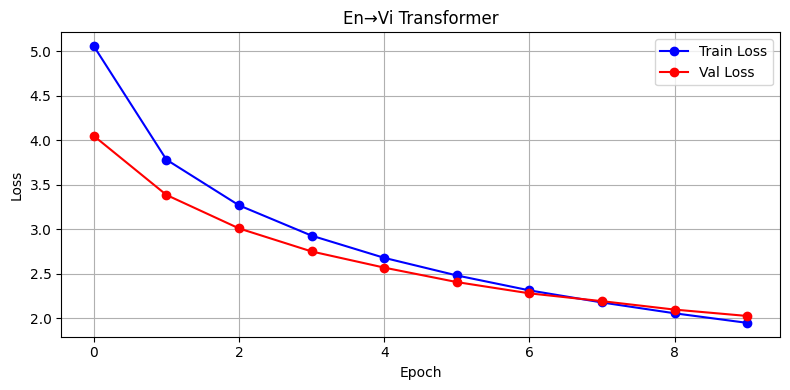


EN      : I love you.
Greedy  : tôi yêu bạn.
Beam(4) : tôi yêu bạn.
Sampling: tôi yêu bạn

EN      : Tom went to school.
Greedy  : tom đi học
Beam(4) : tom đã đi học
Sampling: tom đi học.

EN      : Please close the door.
Greedy  : xin vui lòng đóng cửa
Beam(4) : xin vui lòng đóng cửa
Sampling: vui lòng đóng cửa


In [15]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, "b-o", label="Train Loss")
plt.plot(val_losses,   "r-o", label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("En→Vi Transformer"); plt.legend(); plt.grid(True)
plt.tight_layout(); plt.show()

# So sánh 3 strategies
tests = ["I love you.", "Tom went to school.", "Please close the door."]
for sent in tests:
    print(f"\nEN      : {sent}")
    print(f"Greedy  : {greedy_decode(sent,   model, src_vocab, tgt_vocab)}")
    print(f"Beam(4) : {beam_decode(sent,     model, src_vocab, tgt_vocab, beam_size=4)}")
    print(f"Sampling: {sampling_decode(sent, model, src_vocab, tgt_vocab, temperature=0.9)}")
